# Practice_03

In [1]:
# 필수 라이브러리 Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
import platform

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

print("=" * 60)
print("3회차 실습 과제: 추정과 가설검정")
print("=" * 60)

3회차 실습 과제: 추정과 가설검정


---

## 문제 2: 단일표본 t-검정

### 시나리오: 음료 자판기 용량 검사

자판기 제조사는 커피 한 잔의 용량이 **200ml**이라고 주장합니다.

소비자 보호원이 무작위로 20잔을 측정하여 주장을 검증합니다.

**주어진 데이터:**

In [2]:
print("\n[문제 2] 자판기 용량 검사")
print("=" * 50)

np.random.seed(123)
coffee_ml = np.random.normal(loc=196, scale=6, size=20)
coffee_ml = np.round(coffee_ml, 1)

print(f"측정 데이터 (n = {len(coffee_ml)}잔):")
print(coffee_ml)
print(f"\n표본평균: {np.mean(coffee_ml):.2f}ml")
print(f"표본표준편차: {np.std(coffee_ml, ddof=1):.2f}ml")



[문제 2] 자판기 용량 검사
측정 데이터 (n = 20잔):
[189.5 202.  197.7 187.  192.5 205.9 181.4 193.4 203.6 190.8 191.9 195.4
 204.9 192.2 193.3 193.4 209.2 209.1 202.  198.3]

표본평균: 196.68ml
표본표준편차: 7.54ml


### 문제 2-1: 가설검정 5단계

유의수준 α = 0.05에서, 자판기 용량이 200ml에 미달하는지 검정하세요.

**(a)** 가설을 설정하세요.

**(b)** `stats.ttest_1samp()`으로 검정통계량과 p-value를 구하세요.

**(c)** 결론을 내리세요. (기각 또는 기각 실패, 그 의미)

**(d)** 95% 신뢰구간(양측)을 구하고, 구간에 200이 포함되는지 확인하세요. 그래서 검정 결과와 일관되는지 확인 하세요.

In [5]:
print("\n[문제 2-1] 가설검정 5단계")
print("-" * 40)

mu_0 = 200  # 제조사 주장
alpha = 0.05

# TODO (a): 가설 설정
print("[1단계] 가설 설정")
print('-'*20)
print(f"  H0: mu = {mu_0}  (제조사의 주장대로 200ml)")
print(f"  H1: 자판기의 용량은 200 mL 미만이다.")
print(f"  검정 유형: 단일 표본 t-검정, 하한 단측을 사용할 예정")

print('-'*20)
print(f"\n[2단계] 유의수준: alpha = {alpha}")

# TODO (b): 검정 실행(수정함)✂️
n = len(coffee_ml) #표본의 크기
x_bar = np.mean(coffee_ml) #표본평균
s = np.std(coffee_ml, ddof=1)
se = s / np.sqrt(n) #표준오차

t_stat = (x_bar - mu_0) / se
p_value_two = stats.ttest_1samp(coffee_ml, mu_0)[1]  # stats.ttest_1samp 결과 (양측)
if t_stat < 0:
    p_value = p_value_two / 2 # 표본평균이 200보다 작은 경우
else:                           
    p_value = 1 - p_value_two / 2 # 표본평균이 200보다 큰 경우에 대비

print('-'*20)
print(f"\n[3단계] 검정통계량")
print(f"  t-통계량: {t_stat:.3f}")

print('-'*20)
print(f"\n[4단계] p-value")
print('-'*20)
print(f"  p-value (양측): {p_value_two:.3f}")
print(f"  p-value (사용할 값): {p_value:.3f}")

# TODO (c): 결론
print('-'*20)
print(f"\n[5단계] 결론")
print('-'*20)
if p_value <= alpha:
    print(f'p-value({p_value:.3f}) <= alpha({alpha:.3f})이므로 귀무가설(H0)을 기각합니다.')
else:
    print(f'p-value({p_value:.3f}) > alpha({alpha:.3f})이므로 귀무가설(H0) 기각을 보류합니다.')   



[문제 2-1] 가설검정 5단계
----------------------------------------
[1단계] 가설 설정
--------------------
  H0: mu = 200  (제조사의 주장대로 200ml)
  H1: 자판기의 용량은 200 mL 미만이다.
  검정 유형: 단일 표본 t-검정, 하한 단측을 사용할 예정
--------------------

[2단계] 유의수준: alpha = 0.05
--------------------

[3단계] 검정통계량
  t-통계량: -1.972
--------------------

[4단계] p-value
--------------------
  p-value (양측): 0.063
  p-value (사용할 값): 0.032
--------------------

[5단계] 결론
--------------------
p-value(0.032) <= alpha(0.050)이므로 귀무가설(H0)을 기각합니다.


In [9]:
# TODO (d): 95% 신뢰구간 계산 및 해석(수정함)✂️
print('-'*20)
print(f"\n[6단계]95% 신뢰구간(양측검정, 하한 단측검정)")
print('-'*20)

# 양측 신뢰구간
ci_95_two_sided = stats.t.interval(0.95, df=n-1, loc=x_bar, scale=se)

# 단측 신뢰구간(하한 단측검정 기준)
t_95pct_point = stats.t.ppf(0.95, df=n-1)
ci_95_upper_bound = x_bar + t_95pct_point * se

print(f"95% 신뢰구간(양측): {ci_95_two_sided}")
print(f"95% 신뢰구간(하한 단측): (-∞, {ci_95_upper_bound:.4f})")


print(f"\n[7단계]하한 단측 검정 결과와 95% 신뢰구간의 일관성")
print('-'*20)

print(f"하한 단측 검정 수행(H1: μ < 200):")
if p_value <= alpha:
    print(f"  검정 결과: p-value({p_value:.4f}) ≤ {alpha} → H0 기각")
    print(f"  하한 단측 95% CI 상한값: {ci_95_upper_bound:.4f}")
    if ci_95_upper_bound < 200:
        print(f"  신뢰구간의 상한값 < 200 → 귀무가설을 기각한 검정 결과와 동일합니다.")
else:
    print(f"  검정 결과: p-value({p_value:.4f}) > {alpha} → H0 기각 보류")
    print(f"  하한 단측 95% CI 상한값: {ci_95_upper_bound:.4f}")
    if ci_95_upper_bound >= 200:
        print(f"  신뢰구간의 상한값 ≥ 200 → 귀무가설 기각을 보류한 검정 결과와 동일합니다.")

--------------------

[6단계]95% 신뢰구간(양측검정, 하한 단측검정)
--------------------
95% 신뢰구간(양측): (193.14643747367217, 200.20356252632786)
95% 신뢰구간(하한 단측): (-∞, 199.5901)

[7단계]하한 단측 검정 결과와 95% 신뢰구간의 일관성
--------------------
하한 단측 검정 수행(H1: μ < 200):
  검정 결과: p-value(0.0317) ≤ 0.05 → H0 기각
  하한 단측 95% CI 상한값: 199.5901
  신뢰구간의 상한값 < 200 → 귀무가설을 기각한 검정 결과와 동일합니다.


In [ ]:
print(f"\n[8단계]95% 신뢰구간(양측)과의 관계")
print('-'*20)

if ci_95_two_sided[0] < 200 < ci_95_two_sided[1]:
    print(f"  양측 95% CI: ({ci_95_two_sided[0]:.4f}, {ci_95_two_sided[1]:.4f})")
    print(f"  --> 200이 양측 95% CI에 포함됨")
    
    if p_value <= alpha:
        # 기각했는데 포함 → 모순 아님 설명 필요
        print(f"\n위에서 수행한 검정에서는 귀무가설을 기각했는데, 양측 CI에는 200이 포함되었다?")
        print(f"그렇지만, 모순이라고 할 수 없는 이유는 다음과 같다.")
        
        print(f"\n【이유 1: 유의수준 차이】")
        print(f"  하한 단측 CI에서 95% 신뢰구간이라 함은 상위 5% 값을 상한값이라고 하며 범위에서 제외하지만")
        print(f" 양측 95% CI는 상/하위에서 2.5%의 값을 각각 상한값, 하한값이라고 정의하고 범위에서 제외한다.")
        
        print(f"\n【이유 2: 구간 범위 차이】")
        print(f"  하한 단측 상한값: {ci_95_upper_bound:.4f}")
        print(f" 95% CI(양측): ({ci_95_two_sided[0]:.4f}, {ci_95_two_sided[1]:.4f})")
        print(f" → 양측으로 측정한 CI의 구간이 더 넓어서 200이 포함될 수 있는 것이다.")
        
        print(f"\n따라서 일관성 있는 정상적 현상이라고 할 수 있다.")
    
    else:
        # 기각 실패했고 포함 → 일관성 있음
        print(f"\n  하한 단측 검정 결과와 일관성:")
        print(f"    • 하측 검정: 귀무가설 기각 보류")
        print(f"    • 95% CI(양측): 200 포함")
        print(f"    → 양측 검정 기준으로도 200을 배제할 수 없음")
        print(f"    → 검정결과와 일관된 결과이다.")
            
        
else:
    # 양측 CI에 200 포함되지 않음
    print(f"  양측 95% CI: ({ci_95_two_sided[0]:.4f}, {ci_95_two_sided[1]:.4f})")
    print(f"  --> 200이 양측 95% CI에 포함되지 않음")
    
    if p_value <= alpha:
        # 기각했고 미포함 
        print(f"\n  매우 강력한 증거:")
        print(f"    • 하한 단측 검정: H0 기각")
        print(f"    • 95% CI(양측): 200 미포함")
        print(f"    → 하한 단측뿐만 아니라 양측으로도 유의미하다.")
        print(f"    → μ < 200에 대한 매우 강력한 증거이다.")
        
    else:
        # 기각 실패했고 미포함
        print("하한 단측 검정으로도 귀무가설을 기각하지 못하고, 양측 기준 95% 신뢰구간에 200이 포함되지 않음")
        
        if 200 < ci_95_two_sided[0]:
            print("표본 평균이 200보다 크므로 하안 단측 검정에서 기각되지 않는 것이 당연하다.")
        else:
            print("데이터를 다시 확인해봐야 할 것으로 예상된다.")                        


[8단계]95% 신뢰구간(양측)과의 관계
--------------------
  양측 95% CI: (193.1464, 200.2036)
  --> 200이 양측 95% CI에 포함됨

위에서 수행한 검정에서는 귀무가설을 기각했는데, 양측 CI에는 200이 포함되었다?
그렇지만, 모순이라고 할 수 없는 이유는 다음과 같다.

【이유 1: 유의수준 차이】
  하한 단측 CI에서 95% 신뢰구간이라 함은 상위 5% 값을 상한값이라고 하며 범위에서 제외하지만
 양측 95% CI는 상/하위에서 2.5%의 값을 각각 상한값, 하한값이라고 정의하고 범위에서 제외한다.

【이유 2: 구간 범위 차이】
  하한 단측 상한값: 199.5901
 95% CI(양측): (193.1464, 200.2036)
 → 양측으로 측정한 CI의 구간이 더 넓어서 200이 포함될 수 있는 것이다.

따라서 일관성 있는 정상적 현상이라고 할 수 있다.


---

## 문제 4: 대응표본 t-검정과 검정력

### 시나리오: 영어 학습 앱 효과 검증

교육 회사가 새로운 영어 학습 앱의 효과를 검증합니다.

15명의 학생이 앱 사용 전후에 영어 시험을 치렀습니다.

**주어진 데이터:**

In [11]:
print("\n[문제 4] 영어 학습 앱 효과 검증")
print("=" * 50)

np.random.seed(42)
n_students = 15

before_scores = np.random.normal(loc=65, scale=10, size=n_students)
improvement = np.random.normal(loc=5, scale=6, size=n_students)
after_scores = before_scores + improvement

before_scores = np.round(before_scores, 1)
after_scores = np.round(after_scores, 1)

print(f"{'학생':>4} {'사전':>8} {'사후':>8} {'변화':>8}")
print("-" * 32)
for i in range(n_students):
    diff = after_scores[i] - before_scores[i]
    print(f"  {i+1:>2d}   {before_scores[i]:>6.1f}   {after_scores[i]:>6.1f}   {diff:>+6.1f}")

print(f"\n사전 평균: {np.mean(before_scores):.2f}")
print(f"사후 평균: {np.mean(after_scores):.2f}")
print(f"차이 평균: {np.mean(after_scores - before_scores):.2f}")



[문제 4] 영어 학습 앱 효과 검증
  학생       사전       사후       변화
--------------------------------
   1     70.0     71.6     +1.6
   2     63.6     62.5     -1.1
   3     71.5     78.4     +6.9
   4     80.2     79.8     -0.4
   5     62.7     59.2     -3.5
   6     62.7     76.5    +13.8
   7     80.8     84.4     +3.6
   8     72.7     78.1     +5.4
   9     60.3     56.8     -3.5
  10     70.4     72.2     +1.8
  11     60.4     66.0     +5.6
  12     60.3     58.4     -1.9
  13     67.4     74.7     +7.3
  14     45.9     47.3     +1.4
  15     47.8     51.0     +3.2

사전 평균: 65.11
사후 평균: 67.79
차이 평균: 2.68


### 문제 4-1: 대응표본 t-검정

**(a)** 가설을 설정하세요.

**(b)** 검정을 수행하세요.

**(c)** α = 0.05에서 결론을 내리세요.

**(d)** 차이(d = 사후 - 사전)의 95% 신뢰구간을 구하세요.

In [12]:
print("\n[문제 4-1] 대응표본 t-검정")
print("-" * 40)

alpha = 0.05
diff = after_scores - before_scores #성적 변화량

# TODO (a): 가설 설정
print(f'\n (a) 가설 설정')
print(f' - 귀무가설(H0): 새로운 학습앱을 사용하기 전후 성적 변화는 없거나 감소했을 것이다.')
print(f' - 대립가설(H1): 새로운 학습앱을 사용한 후, 성적은 향상되었다.')
print(f"  검정 유형: 대응표본 t-검정, 우측(상측) 검정 사용 예정")
print(f"  ※ diff = 학습후 - 학습전")

# TODO (b): 대응표본 t-검정
print(f'\n (b) 대응표본 t-검정')

t_stat, p_value = stats.ttest_rel(after_scores, before_scores, alternative='greater')
print(f'  t-통계량: {t_stat:.4f}')
print(f'  p-value: {p_value:.4f}')
print(f"  차이 평균 (학습후 - 학습전): {np.mean(diff):.3f}")
print(f"  차이 표준편차: {np.std(diff, ddof=1):.3f}")


# TODO (c): 결론
print(f'\n (c) 결론')
if p_value <= alpha:
    print(f'   p-value({p_value:.4f}) <= alpha({alpha:.4f})이므로 귀무가설(H0)을 기각합니다.')
    print(f'   즉, 새로운 학습앱 사용 후에 성적이 통계적으로 유의미하게 상승했을 것으로 보입니다.')
else:
    print(f'   p-value({p_value:.4f}) > alpha({alpha:.4f})이므로 귀무가설(H0) 기각을 보류합니다.')   
    print(f'   즉, 새로운 학습앱 사용 후에 성적이 통계적으로 유의미하게 상승한다는 증거를 얻지 못했습니다.')
    
# TODO (d): 차이의 95% 신뢰구간
n = len(diff) #표본의 크기

mean_diff = np.mean(diff) #표본평균
sem_diff = stats.sem(diff) #표본오차(SEM)

ci_low, ci_high = stats.t.interval(0.95, df = n-1, loc = mean_diff, scale = sem_diff)

print(f'\n (d) 차이의 95% 신뢰구간')
print(f"      표본 집단의 평균 성적 변화량: {mean_diff:.3f}점")
print(f"      95% 신뢰구간: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"      95% 신뢰도로 실제 평균 점수 향상은 {ci_low:.3f}점에서 {ci_high:.3f}점 사이로 예상됩니다.")


[문제 4-1] 대응표본 t-검정
----------------------------------------

 (a) 가설 설정
 - 귀무가설(H0): 새로운 학습앱을 사용하기 전후 성적 변화는 없거나 감소했을 것이다.
 - 대립가설(H1): 새로운 학습앱을 사용한 후, 성적은 향상되었다.
  검정 유형: 대응표본 t-검정, 우측(상측) 검정 사용 예정
  ※ diff = 학습후 - 학습전

 (b) 대응표본 t-검정
  t-통계량: 2.2254
  p-value: 0.0215
  차이 평균 (학습후 - 학습전): 2.680
  차이 표준편차: 4.664

 (c) 결론
   p-value(0.0215) <= alpha(0.0500)이므로 귀무가설(H0)을 기각합니다.
   즉, 새로운 학습앱 사용 후에 성적이 통계적으로 유의미하게 상승했을 것으로 보입니다.

 (d) 차이의 95% 신뢰구간
      표본 집단의 평균 성적 변화량: 2.680점
      95% 신뢰구간: [0.097, 5.263]
      95% 신뢰도로 실제 평균 점수 향상은 0.097점에서 5.263점 사이로 예상됩니다.


---
---
# Practice 04

In [13]:
# 필수 라이브러리 Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
import platform

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("4회차 실습 과제: 비모수 검정, 카이제곱 검정")
print("=" * 60)


4회차 실습 과제: 비모수 검정, 카이제곱 검정


---

## 문제 3: 요일별 고객 방문 패턴 분석

한 음식점 사장이 "요일에 따라 방문 고객 수가 다르지 않다"고 주장합니다.

한 주간 방문 고객 수를 조사하여 이 주장을 검증합니다.

총 **420명**의 고객이 방문했습니다.

**분석 목표**: 요일별 고객 방문 비율이 균등(각 1/7)한지 검정합니다.

**주어진 데이터:**

In [14]:
print("\n[문제 3] 요일별 고객 방문 패턴 분석")
print("=" * 50)

np.random.seed(503)
days = ['월', '화', '수', '목', '금', '토', '일']
true_probs = [0.10, 0.10, 0.12, 0.12, 0.16, 0.22, 0.18]
visits = np.random.choice(days, size=420, p=true_probs)
observed_visits = np.array([np.sum(visits == d) for d in days])

print(f"요일별 방문 고객 수 (총 {observed_visits.sum()}명):")
df_visits = pd.DataFrame({'요일': days, '관측 빈도': observed_visits})
display(df_visits)



[문제 3] 요일별 고객 방문 패턴 분석
요일별 방문 고객 수 (총 420명):


,요일,관측 빈도
0,월,50
1,화,43
2,수,40
3,목,54
4,금,69
5,토,89
6,일,75


### 문제 3-1: 가설 설정 및 적합도 검정

**(a)** 분석 목표에 맞는 **귀무가설(H₀)** 과 **대립가설(H₁)** 을 설정하세요.

> 카이제곱 검정은 "차이가 존재하는가?"를 판정하므로 양측/단측 개념이 적용되지 않습니다.

**(b)** 기대빈도를 계산하고, Cochran's rule을 확인하세요.

기대빈도 < 5인 셀이 전체의 20%를 초과하거나 기대빈도 < 1인 셀이 있는지 점검하세요.

**(c)** 적합도 검정을 수행하세요 (α = 0.05).

**(d)** 결론을 내리세요.

In [15]:
print("\n[문제 3-1] 가설 설정 및 적합도 검정")
print("-" * 40)

# TODO (a): 가설 설정
print("(a) 가설 설정:")
print(f"    H₀: 요일별 고객 방문 비율은 균등하다.")
print(f"    H₁: 요일별 고객 방문 비율은 균등하지 않다.")

# TODO (b): 기대빈도 + Cochran's rule 확인(수정함)✂️
n_total_visits = observed_visits.sum()
n_categories = len(observed_visits)
expected_visits = np.array([n_total_visits / len(days)]*n_categories)  # 균등 분포 가정 하의 기대빈도

print(f"\n(b) 기대빈도: {expected_visits}")

# Cochran's rule 점검
min_expected = expected_visits.min()
under5_cells = expected_visits[expected_visits < 5]
num_5under_cells = len(under5_cells)
ratio_5under_cells = (num_5under_cells / n_categories) * 100

if min_expected < 1 or ratio_5under_cells > 20:
    print("Cochran's rule을 만족하지 않음")
    print(f"기대빈도가 1 미만인 셀이 존재하는가? {'아니오' if min_expected >= 1 else '예'}")
    print(f"기대빈도가 5 미만인 셀의 비율: {ratio_5under_cells:.2f}%")      
    print(f"기대빈도가 5 미만인 셀의 개수: {num_5under_cells}")      
else:
    print("Cochran's rule을 만족함")    
    print(f"기대빈도가 1 미만인 셀이 존재하는가? {'아니오' if min_expected >= 1 else '예'}")
    print(f"기대빈도가 5 미만인 셀의 비율: {ratio_5under_cells:.2f}%")
    print(f"기대빈도가 5 미만인 셀의 개수: {num_5under_cells}")     

# TODO (c): 적합도 검정
chi2_visits, p_visits = stats.chisquare(f_obs=observed_visits, f_exp=expected_visits)

print(f"\n(c) 적합도 검정:")
print(f"    χ² = {chi2_visits:.4f}")
print(f"    자유도 (df) = {len(days) - 1}")
print(f"    p-value = {p_visits:.6f}")

# TODO (d): 결론
print(f"\n(d) 결론 (α=0.05):")

alpha = 0.05
if p_visits < alpha:
    print(f"    귀무가설 기각 -> 요일별 고객 방문 비율은 균등하지 않다.")
else:    
    print(f"    귀무가설 기각 보류 -> 요일별 고객 방문 비율은 균등하다.")


[문제 3-1] 가설 설정 및 적합도 검정
----------------------------------------
(a) 가설 설정:
    H₀: 요일별 고객 방문 비율은 균등하다.
    H₁: 요일별 고객 방문 비율은 균등하지 않다.

(b) 기대빈도: [60. 60. 60. 60. 60. 60. 60.]
Cochran's rule을 만족함
기대빈도가 1 미만인 셀이 존재하는가? 아니오
기대빈도가 5 미만인 셀의 비율: 0.00%
기대빈도가 5 미만인 셀의 개수: 0

(c) 적합도 검정:
    χ² = 32.8667
    자유도 (df) = 6
    p-value = 0.000011

(d) 결론 (α=0.05):
    귀무가설 기각 -> 요일별 고객 방문 비율은 균등하지 않다.


### 문제 3-3: 소규모 카페 음료 선호도

위와 별개 상황입니다. 한 소규모 카페에서 5가지 음료의 선호도가 균등한지 조사했습니다.

총 **22명**의 고객이 응답했습니다.

**분석 목표**: 5가지 음료의 선호도가 균등(각 1/5)한지 검정합니다.

**주어진 데이터:**

In [17]:
print("\n[문제 3-3] 소규모 카페 음료 선호도")
print("-" * 40)

menu = ['아메리카노', '라떼', '카푸치노', '스무디', '에이드']
observed_small = np.array([8, 5, 4, 3, 2])
n_total_small = observed_small.sum()

print(f"음료별 선호 고객 수 (총 {n_total_small}명):")
df_small = pd.DataFrame({'음료': menu, '관측 빈도': observed_small})
display(df_small)


[문제 3-3] 소규모 카페 음료 선호도
----------------------------------------
음료별 선호 고객 수 (총 22명):


,음료,관측 빈도
0,아메리카노,8
1,라떼,5
2,카푸치노,4
3,스무디,3
4,에이드,2


In [ ]:
# TODO (a): 가설 설정
print("(a) 가설 설정:")
print(f"    H₀: 5가지 음료의 선호도는 균등하다.")
print(f"    H₁: 5가지 음료의 선호도는 균등하지 않다.")

# TODO (b): 기대빈도 + Cochran's rule
expected_small = n_total_small / len(menu)  # 균등 분포: n_total / 5
expected_small_real = np.array([expected_small]*5)

print(f"\n(b) 기대빈도: {expected_small}") # 4.4

under5_cells_cnt = np.sum(expected_small_real < 5)
pct_under5_cells = (under5_cells_cnt / len(menu)) *100

print(f"    기대빈도 < 5인 셀: {under5_cells_cnt}개 ({pct_under5_cells}%)")
print(f"    Cochran's rule: {'기대빈도가 5 미만인 셀이 20%를 초과하여 존재해 위배됨' if pct_under5_cells > 20 else '충족함'}")

# TODO (c): 대안 방법 선택(수정함)✂️
print(f"\n(c) 대안 방법 선택 및 선택 이유:")

# 1. 범주 병합(Category Collapsing)의 특성
analysis_merging = (
    "범주 병합 방식은 기대빈도가 낮은 '스무디', '에이드' 등을 합쳐 가정을 충족시킬 수 있으나, "
    "이 과정에서 개별 메뉴의 선호도 정보가 사라지는 '정보 손실(Information Loss)'이 발생할 수 있다."
)

# 2. Monte Carlo 시뮬레이션의 특성
analysis_monte = (
    "Monte Carlo 시뮬레이션은 데이터의 범주 구조를 그대로 유지하면서 무작위 추출을 통해 p-value를 추정하므로, "
    "표본 크기가 작아도 정보 손실 없이 통계적 유의성을 검정할 수 있는 장점이 있다.")

print(f"1) 범주 병합의 한계: {analysis_merging}")
print(f"2) Monte Carlo의 장점: {analysis_monte}")
print(f"\n결론: 각 음료수의 고유한 특징을 유지하면서 분석의 정밀도를 높이기 위해 Monte Carlo 시뮬레이션을 적용할 것이다.")


# TODO (d): 검정 수행 (선택한 대안) -> Monte Carlo 시뮬레이션

# 카이제곱 검정(참고용)
chi2_small_1, p_small = stats.chisquare(observed_small, expected_small_real)

# print(ch2_small) -> 4.81
# print(p_small) -> 0.306 -> 균일분포와 같을 것이다

n_simulation = 100_000 #십만번 반복
count_extreme = 0 #극단값의 개수

# 귀무가설 하에서 각각의 메뉴를 선택할 확률 -> 1/5
expected_prob = [1/len(menu)] * len(menu)

for i in range(n_simulation):
    # 귀무가설이 참이라는 가정 하에 만든 샘플
    sample = np.random.multinomial(n_total_small, expected_prob)
    
    # 시뮬레이션 데이터의 카이제곱 통계량
    chi2_small_2 = np.sum((sample - expected_small_real)**2 / expected_small_real).round(5) 
    if chi2_small_2 > chi2_small_1:
        count_extreme += 1
    
    
p_alternative = count_extreme / n_simulation

print(f"\n(d) 검정 결과:")
print(f"    p-value: {p_alternative}")
print(f"    판정 (α=0.05): 귀무가설 기각을 보류한다. 즉, 5가지 음료의 선호도는 균등하다.")

# TODO (e): 효과크기
cohens_w_small = np.sqrt(chi2_small_1 / n_total_small)

print(f"\n(e) Cohen's w = {cohens_w_small}")
print(f"    해석: 이는 {'작은' if cohens_w_small < 0.3 else '중간' if cohens_w_small < 0.5 else '큰'}효과이다.")
print(f"         효과크기가 약 0.468로, 중간보다는 큰 효과이다.")



(a) 가설 설정:
    H₀: 5가지 음료의 선호도는 균등하다.
    H₁: 5가지 음료의 선호도는 균등하지 않다.

(b) 기대빈도: 4.4
    기대빈도 < 5인 셀: 5개 (100.0%)
    Cochran's rule: 기대빈도가 5 미만인 셀이 20%를 초과하여 존재해 위배됨

(c) 대안 방법 선택 및 선택 이유:
1) 범주 병합의 한계: 범주 병합 방식은 기대빈도가 낮은 '스무디', '에이드' 등을 합쳐 가정을 충족시킬 수 있으나, 이 과정에서 개별 메뉴의 선호도 정보가 사라지는 '정보 손실(Information Loss)'이 발생할 수 있다.
2) Monte Carlo의 장점: Monte Carlo 시뮬레이션은 데이터의 범주 구조를 그대로 유지하면서 무작위 추출을 통해 p-value를 추정하므로, 표본 크기가 작아도 정보 손실 없이 통계적 유의성을 검정할 수 있는 장점이 있다.

결론: 각 음료의 고유한 의미를 유지하며 분석의 정밀도를 높이기 위해 Monte Carlo 시뮬레이션을 적용할 것이다.

(d) 검정 결과:
    p-value: 0.27128
    판정 (α=0.05): 귀무가설 기각을 보류한다. 즉, 5가지 음료의 선호도는 균등하다.

(e) Cohen's w = 0.4679831882266818
    해석: 이는 중간효과이다.
         효과크기가 약 0.468로, 중간보다는 큰 효과이다.


---
---
# Practice 05

In [20]:
# 필수 라이브러리 Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
import pingouin as pg
import scikit_posthocs as sp
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize, proportion_confint, confint_proportions_2indep
from statsmodels.stats.power import NormalIndPower
from scipy.stats import skew
import seaborn as sns
import warnings
import platform

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("5회차 실습 과제")
print("=" * 60)

5회차 실습 과제


---

## 문제 3: 앱 UI 변경 A/B 테스트 (전환율 비교)

모바일 쇼핑 앱에서 결제 화면 UI를 개선하면 **구매 전환율**이 높아지는지 A/B 테스트를 수행합니다.

- **대조군(A)**: 기존 결제 화면
- **실험군(B)**: 개선된 결제 화면 (버튼 크기 확대 + 단계 축소)
- **지표**: 구매 전환율 (결제 완료 비율)
- **현재 전환율**: 8%
- **비즈니스 목표**: 최소 2%p 이상 개선을 탐지하고 싶음 (8% → 10%)

**분석 목표**: 개선된 UI가 기존 대비 전환율을 유의하게 높이는지 검정합니다.

---

### 문제 3-1: 실험 설계 — 표본 크기 산정

A/B 테스트를 실행하기 **전에** 필요한 표본 크기를 산정합니다.

**(a)** 실험 설계 파라미터를 정리하세요.

**(b)** **효과크기(Cohen's h)** 를 계산하세요.

**(c)** **집단당 필요 표본 크기**를 산정하세요.

**(d)** 양측검정과 단측검정 각각에 대해 표본 크기를 구하고, 차이를 비교하세요.
이 실험에서는 어떤 검정이 더 적절한지 근거와 함께 설명하세요.

In [21]:
print("\n[문제 3] 앱 UI 변경 A/B 테스트")
print("=" * 50)
print("\n[문제 3-1] 실험 설계 — 표본 크기 산정")
print("-" * 40)

baseline_rate = 0.08   # 기존 전환율
mde = 0.02             # 최소 탐지 효과 (2%p)
alpha = 0.05           # 유의수준
power_target = 0.80    # 검정력

target_rate = baseline_rate + mde  # 목표 전환율

# TODO (a): 파라미터 정리
print("(a): 파라미터 정리")
print("-" * 40)
print(f"  기존 전환율 (p₀): {baseline_rate:.0%}")
print(f"  목표 전환율 (p₁): {target_rate:.0%}")
print(f"  MDE (최소 탐지 효과): {mde:.0%}p")
print(f"  유의수준: {alpha}")
print(f"  검정력: {power_target:.0%}")


[문제 3] 앱 UI 변경 A/B 테스트

[문제 3-1] 실험 설계 — 표본 크기 산정
----------------------------------------
(a): 파라미터 정리
----------------------------------------
  기존 전환율 (p₀): 8%
  목표 전환율 (p₁): 10%
  MDE (최소 탐지 효과): 2%p
  유의수준: 0.05
  검정력: 80%


In [22]:
# TODO (b): 효과크기 (Cohen's h)
print("(b): 효과크기 (Cohen's h)")
print("-" * 40)

effect_size = abs(proportion_effectsize(target_rate, baseline_rate))

print(f"  효과크기 (Cohen's h): {effect_size:.2f}")

(b): 효과크기 (Cohen's h)
----------------------------------------
  효과크기 (Cohen's h): 0.07


In [23]:
# TODO (c): 필요 표본 크기
print("(c): 표본 크기 산정")
print("-" * 40)

# NormalIndPower: 정규분포 기반 독립 표본 검정력 분석 클래스
power_analysis = NormalIndPower()
sample_size_two_sides = power_analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power_target,
    alternative='two-sided'
)

print(f"  집단당 필요한 표본 크기(양측검정): {np.ceil(sample_size_two_sides):,.0f}명")

(c): 표본 크기 산정
----------------------------------------
  집단당 필요한 표본 크기(양측검정): 3,205명


In [ ]:
# TODO (d): 양측 vs 단측 비교 및 선택 (수정함)✂️
print("(d): 양측 vs 단측 비교 및 선택")
print("-" * 40)

# 단측검정 목적: 결제 화면을 개선하면 전환율이 기존보다 높아지는가?
sample_size_larger = power_analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power_target,
    alternative='larger'
)

print(f"  집단당 필요한 표본 크기(단측검정): {np.ceil(sample_size_larger):,.0f}명")
print(f"  집단당 필요한 표본 크기(양측검정): {np.ceil(sample_size_two_sides):,.0f}명")

my_opinion_5 = f"""\n--> --> 본 실험의 목적은 '결제 화면 개선이 구매 전환율의 상승을 이끌어내는가'를 검증하는 것입니다.
따라서 UI 개선을 통해 성과가 향상되는 방향성(Directionality)을 확인하는 것이 핵심이므로 단측 검정(larger)을 선택하는 것이 논리적으로 타당합니다.

단측 검정을 선택할 경우, 양측 검정 대비 동일한 유의수준과 검정력 하에서 필요한 표본 크기를 줄일 수 있어 실험 비용과 시간을 절약하는 경제적 이점이 있습니다.
물론 반대 방향(성과 하락)에 대한 검정력은 포기하게 되지만, 비즈니스 관점에서 '개선'의 여부를 명확히 입증하는 것이 우선순위이므로 효율적이고 목적 지향적인 
단측 검정을 최종적으로 선택하고자 한다.
"""

print(my_opinion_5)


(d): 양측 vs 단측 비교 및 선택
----------------------------------------
  집단당 필요한 표본 크기(단측검정): 2,525명
  집단당 필요한 표본 크기(양측검정): 3,205명

--> --> 본 실험의 목적은 '결제 화면 개선이 구매 전환율의 상승을 이끌어내는가'를 검증하는 것입니다.
따라서 UI 개선을 통해 성과가 향상되는 방향성(Directionality)을 확인하는 것이 핵심이므로 단측 검정(larger)을 선택하는 것이 논리적으로 타당합니다.

단측 검정을 선택할 경우, 양측 검정 대비 동일한 유의수준과 검정력 하에서 필요한 표본 크기를 줄일 수 있어 실험 비용과 시간을 절약하는 경제적 이점이 있습니다.
물론 반대 방향(성과 하락)에 대한 검정력은 포기하게 되지만, 비즈니스 관점에서 '개악'인 경우를 탐색하기보다 '개선'의 여부를 명확히 입증하는 것이 우선순위이므로
효율적이고 목적 지향적인 단측 검정을 최종적으로 선택하고자 합니다.



### 문제 3-2: A/B 테스트 실행 및 검정

실험을 진행하여 아래 데이터를 수집했습니다.

**(a)** 각 집단의 전환율을 계산하세요.

**(b)** **z-비율검정**을 수행하세요.

> `proportions_ztest(count, nobs, alternative=...)`

**(c)** **효과크기(Cohen's h)** 를 관측된 전환율로 계산하세요.

**(d)** 각 집단의 **95% 신뢰구간**을 구하세요.

> `proportion_confint(count, nobs, alpha=0.05, method='wilson')`

**(e)** **비율 차이의 95% 신뢰구간**을 구하세요.

> `confint_proportions_2indep(count1, nobs1, count2, nobs2, method='wald')`

**(f)** **상대적 개선율(Relative Lift)** 을 계산하세요.

> 상대적 개선율 = (실험군 전환율 − 대조군 전환율) / 대조군 전환율 × 100

**(g)** 전환율 비교 막대 그래프를 그리세요 (95% 신뢰구간 포함).

In [25]:
print("\n[문제 3-2] A/B 테스트 실행 및 검정")
print("-" * 40)

np.random.seed(553)
n_per_group = 2600  # 실험에 참여한 인원 (집단당)

# 데이터 생성 (시뮬레이션)
control_conv = np.random.binomial(1, 0.08, n_per_group)    # 대조군: 8%
treatment_conv = np.random.binomial(1, 0.105, n_per_group)  # 실험군: 10.5%

# TODO (a): 전환율 계산
print("(a): 각 집단의 전환율 계산")
print("-" * 40)

# 구매 전환율(CVR)
cvr_of_control_groups = control_conv.mean() # 대조군
cvr_of_treatment_groups = treatment_conv.mean() # 실험군

print(f"대조군(기존 결제 화면 노출)의 구매 전환율: {cvr_of_control_groups:.4f}({cvr_of_control_groups:.2%})")
print(f"실험군(개선된 결제 화면 노출)의 구매 전환율: {cvr_of_treatment_groups:.4f}({cvr_of_treatment_groups:.2%})")


[문제 3-2] A/B 테스트 실행 및 검정
----------------------------------------
(a): 각 집단의 전환율 계산
----------------------------------------
대조군(기존 결제 화면 노출)의 구매 전환율: 0.0831(8.31%)
실험군(개선된 결제 화면 노출)의 구매 전환율: 0.1112(11.12%)


In [26]:
# TODO (b): z-비율검정(수정함)✂️
print("(b): z-비율검정(단측 검정) 결과")
print("-" * 40)

count = np.array([treatment_conv.sum(), control_conv.sum()]) # 각 집단의 전환 성공 수
nobs = np.array([n_per_group, n_per_group]) # 각 집단의 전체 관측 수

# z-비율검정
z_stat, z_p = proportions_ztest(count, nobs, alternative='larger')

print(f"z 통계량: {z_stat:.4f}") # 3.4187
print(f"p-value: {z_p:.4f}") # 0.0003

# 단측 z-비율검정 결과 분석
print(f"단측 z-비율검정 결과: {'귀무가설을 기각한다.' if z_p < alpha else '귀무가설 기각을 보류한다.'}")


(b): z-비율검정(단측 검정) 결과
----------------------------------------
z 통계량: 3.4187
p-value: 0.0003
단측 z-비율검정 결과: 귀무가설을 기각한다.


In [27]:
# TODO (c): 관측된 효과크기 (Cohen's h)(수정함)✂️
print("(c): 관측된 효과크기 (Cohen's h)")
print("-" * 40)

h = proportion_effectsize(cvr_of_control_groups, cvr_of_treatment_groups)
print(f"효과크기 (Cohen's h) = {h:.4f}")

(c): 관측된 효과크기 (Cohen's h)
----------------------------------------
효과크기 (Cohen's h) = -0.0951


In [28]:
# TODO (d): 실험군, 대조군 95% 신뢰구간
print("(d): 실험군, 대조군 각각의 95% 신뢰구간")
print("-" * 40)

# 대조군 신뢰구간
ci_low_c, ci_upp_c = proportion_confint(count[1], nobs[1], alpha=0.05, method='wilson')

# 실험군 신뢰구간
ci_low_t, ci_upp_t = proportion_confint(count[0], nobs[0], alpha=0.05, method='wilson')

print(f"대조군의 95% 신뢰구간: [{ci_low_c:.4f}, {ci_upp_c:.4f}]")
print(f"실험군의 95% 신뢰구간: [{ci_low_t:.4f}, {ci_upp_t:.4f}]")

(d): 실험군, 대조군 각각의 95% 신뢰구간
----------------------------------------
대조군의 95% 신뢰구간: [0.0731, 0.0943]
실험군의 95% 신뢰구간: [0.0996, 0.1238]


In [29]:
# TODO (e): 비율 차이의 95% 신뢰구간
print("(e): 실험군, 대조군의 구매전환율 차이의 95% 신뢰구간")
print("-" * 40)

ci_low, ci_upp = confint_proportions_2indep(
    count[0], nobs[0],   # treatment: 성공 수, 표본 크기
    count[1], nobs[1],   # control: 성공 수, 표본 크기
    method='wald'        # method: 'wald'(정규근사, 대표본), 'newcombe'(Wilson 기반, 소표본 디폴트 값),
)

diff = cvr_of_treatment_groups - cvr_of_control_groups
print(f"두 집단의 구매 전환율 차이: {diff:.4f}({diff:.2%})")
print(f"95% 신뢰구간: [{ci_low:.4f}, {ci_upp:.4f}]")

(e): 실험군, 대조군의 구매전환율 차이의 95% 신뢰구간
----------------------------------------
두 집단의 구매 전환율 차이: 0.0281(2.81%)
95% 신뢰구간: [0.0120, 0.0442]


In [30]:
# TODO (f): 상대적 개선율
print("(f): 상대적 개선율")
print("-" * 40)

relative_lift = ((cvr_of_treatment_groups - cvr_of_control_groups) / cvr_of_control_groups)*100

print(f"상대적 개선율: {relative_lift:.3f} %")

(f): 상대적 개선율
----------------------------------------
상대적 개선율: 33.796 %


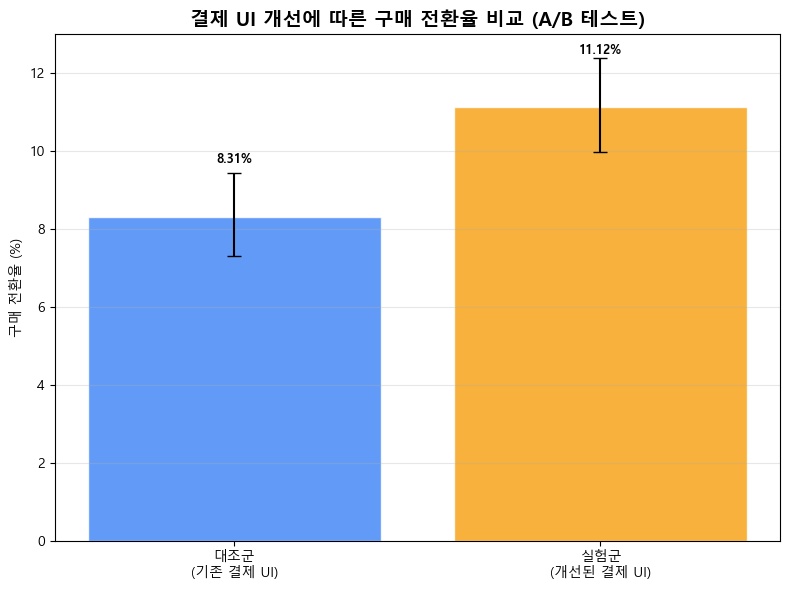

In [31]:
# TODO (g): 전환율 비교 막대 그래프 (신뢰구간 포함)(수정함)✂️
fig, ax = plt.subplots(figsize=(8, 6))

# TODO: 막대 그래프 그리기
labels = ['대조군\n(기존 결제 UI)', '실험군\n(개선된 결제 UI)']
rates = [cvr_of_control_groups * 100, cvr_of_treatment_groups * 100]
bar_colors = ['#3B82F6', '#F59E0B']
bars = ax.bar(labels, rates, color=bar_colors, alpha=0.8, edgecolor='white')

# 오차막대 (신뢰구간)
cis_low = [ci_low_c * 100, ci_low_t * 100]
cis_upp = [ci_upp_c * 100, ci_upp_t * 100]
yerr_low = [r - l for r, l in zip(rates, cis_low)]
yerr_upp = [u - r for u, r in zip(cis_upp, rates)]

ax.errorbar(labels, rates, 
            yerr=[yerr_low, yerr_upp],
            fmt='none', color='black', capsize=5)

# 전환율 텍스트
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2., rate + 1.3,
            f'{rate:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('구매 전환율 (%)', fontsize=10)
ax.set_title('결제 UI 개선에 따른 구매 전환율 비교 (A/B 테스트)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 문제 3-3: 비즈니스 의사결정

**(a)** A/B 테스트 결과를 종합하여, UI 변경을 **전체 사용자에게 적용할지** 의사결정을 내리세요.
아래 항목을 모두 포함하여 보고서 형식으로 작성하세요.

> | 항목 | 내용 |
> |------|------|
> | 통계적 유의성 | p-value와 유의수준 비교 |
> | 효과크기 | Cohen's h와 해석 |
> | 실무적 의미 | 상대적 개선율과 비즈니스 임팩트 |
> | 신뢰구간 | 비율 차이의 신뢰구간과 두 집단의 신뢰구간 겹침 여부 |
> | 최종 권고 | 적용 / 미적용 / 추가 실험 필요 |

**(b)** 만약 p-value는 유의하지만 효과크기가 매우 작다면(예: Cohen's h < 0.1),
어떤 의사결정이 적절한지 설명하세요.

In [33]:
print("\n[문제 3-3] 비즈니스 의사결정")
print("-" * 40)

# TODO (a): 종합 보고서
print("(a) A/B 테스트 결과 보고서:")

# 통계적 유의성
if z_p < alpha:
    print(f"  [통계적 유의성] p-value({z_p:.4f})가 유의수준({alpha})보다 작으므로 귀무가설을 기각한다.")
else:
    print(f"  [통계적 유의성] p-value({z_p:.4f})가 유의수준({alpha})이상이므로 귀무가설 기각을 보류한다.")


# 효과크기
size_h = '매우 작은' if abs(h) < 0.2 else '작은' if abs(h) < 0.5 else '중간' if abs(h) < 0.8 else '큰'
print(f"\n  [효과크기] Cohen's h = {abs(h):.4f} ({size_h} 효과)")


# 실무적 의미
if relative_lift > 0.001:
    analysis_1 = '기존 전환율 대비 실험군의 전환율이 개선되었다.'
elif abs(relative_lift) < 0.001:
    analysis_1 = '기존 전환율과 실험군의 전환율 차이는 0.001 미만이다.' 
else:
    analysis_1 = '기존 전환율 대비 실험군의 전환율은 오히려 감소하였다.'

if relative_lift > 0.001:
    analysis_2 = '구매 전환율이 개선되면서 소비자 1인당 평균 매출이 증가되는 효과가 기대된다.'     
elif abs(relative_lift) < 0.001:
    analysis_2 = '기존 전환율과 실험군의 전환율 차이는 0.001 미만이므로 결제 화면의 UI 개선을 위한 투자 비용이 낭비된 것으로 사료된다.'
else:
    analysis_2 = '기존 전환율 대비 실험군의 전환율은 오히려 감소하였으므로, 개선된 결제 화면 UI가 오히려 소비자의 불편을 유발했을 가능성이 있다.'

print(f"\n  [실무적 의미] 상대적 개선율이 {relative_lift:.3f} %로, {analysis_1}")
print(f"              따라서 {analysis_2}")


# 신뢰구간 검정
# Q1. 두 집단의 신뢰구간은 겹치는가?
if ci_upp_c >= ci_low_t:
    analysis_3 = '겹친다.'
else:
    analysis_3 = '겹치지 않는다.'
    

# Q2. 두 집단의 비율차이의 신뢰구간은 0을 포함하는가?
if ci_low > 0 or ci_upp < 0:
    analysis_4 = '0을 포함하지 않으므로 두 집단 간 구매 전환율에는 분명한 차이가 있다는 것을 알 수 있다.'
else:
    analysis_4 = '0을 포함하므로 두 집단 간 구매 전환율에는 유의미한 차이가 있으리라 확신할 수 없다.'

print(f"\n  [신뢰구간] 대조군과 실험군의 95% 신뢰구간은 {analysis_3}")
print(f"           두 집단의 구매전환율 차이의 95% 신뢰구간은 {analysis_4}")


# 최종 권고
my_opinion_6 = f"""\n  [최종 권고] 개선된 결제 화면 UI를 적용하기 전에 비용 대비 효과 등을 살펴봐야 한다고 생각한다. 그 이유는 다음과 같다.

  첫째, A/B테스트를 수행하고 진행한 Z-비율검정을 통해 얻은 p-value({z_p:.4f})가 유의수준인 {alpha}보다 작아 귀무가설인 기존 대비 구매 전환율에서는 유의미한 차이가 없다를 기각할 수 있다.
   귀무가설을 기각함으로써 실험군과 대조군의 구매 전환율에는 통계적으로 유의미한 차이가 있을 것으로 보인다.
  둘째, 개선된 결제 화면 UI를 노출한 실험군과 기존 결제 화면 UI를 노출한 대조군 사이에 구매 전환율 차이가 목표 MDE였던 2%p를 달성하였다.
  셋째, 두 집단의 신뢰구간은 서로 겹치지 않고, 두 집단 간의 구매 전환율 차이의 신뢰구간도 0을 포함하지 않는다. 이를 통해 두 집단 간에는 유의한 구매 전환율 차이가 있을 것으로 예상된다.
  넷째, 상대적 개선율을 확인해봤을 때도 상대 개선율은 {relative_lift:.3f}%로 양수이다.

  그러나 효과크기가 {h:.4f}로 매우 작다. 따라서 곧바로 개선된 결제 화면 UI를 전체 사용자에게 적용하는 것보다는 비용 대비 효과를 평가해봐야 한다고 생각한다.
"""

print(my_opinion_6)


[문제 3-3] 비즈니스 의사결정
----------------------------------------
(a) A/B 테스트 결과 보고서:
  [통계적 유의성] p-value(0.0003)가 유의수준(0.05)보다 작으므로 귀무가설을 기각한다.

  [효과크기] Cohen's h = 0.0951 (매우 작은 효과)

  [실무적 의미] 상대적 개선율이 33.796 %로, 기존 전환율 대비 실험군의 전환율이 개선되었다.
              따라서 구매 전환율이 개선되면서 소비자 1인당 평균 매출이 증가되는 효과가 기대된다.

  [신뢰구간] 대조군과 실험군의 95% 신뢰구간은 겹치지 않는다.
           두 집단의 구매전환율 차이의 95% 신뢰구간은 0을 포함하지 않으므로 두 집단 간 구매 전환율에는 분명한 차이가 있다는 것을 알 수 있다.

  [최종 권고] 개선된 결제 화면 UI를 적용하기 전에 비용 대비 효과 등을 살펴봐야 한다고 생각한다. 그 이유는 다음과 같다.

  첫째, A/B테스트를 수행하고 진행한 Z-비율검정을 통해 얻은 p-value(0.0003)가 유의수준인 0.05보다 작아 귀무가설인 기존 대비 구매 전환율에서는 유의미한 차이가 없다를 기각할 수 있다.
   귀무가설을 기각함으로써 실험군과 대조군의 구매 전환율에는 통계적으로 유의미한 차이가 있을 것으로 보인다.
  둘째, 개선된 결제 화면 UI를 노출한 실험군과 기존 결제 화면 UI를 노출한 대조군 사이에 구매 전환율 차이가 목표 MDE였던 2%p를 달성하였다.
  셋째, 두 집단의 신뢰구간은 서로 겹치지 않고, 두 집단 간의 구매 전환율 차이의 신뢰구간도 0을 포함하지 않는다. 이를 통해 두 집단 간에는 유의한 구매 전환율 차이가 있을 것으로 예상된다.
  넷째, 상대적 개선율을 확인해봤을 때도 상대 개선율은 33.796%로 양수이다.

  그러나 효과크기가 -0.0951로 매우 작다. 따라서 곧바로 개선된 결제 화면 UI를 전체 사용자에게 적용하는 것보다는 비용 대비 

In [35]:
# TODO (b): 유의하지만 효과 작은 경우(수정함)✂️
print(f"\n(b) p 유의 + 효과크기 작은 경우의 의사결정:")

my_opinion_11 = """현재 데이터가 해당되는 경우로, p-value는 유의수준 이하이지만 효과크기가 작은 경우에는
표본크기가 큰 상황에서 생길 수 있는 과검정력 현상일 가능성을 배제할 수 없다.

과검정력이란 표본 크기가 매우 커짐에 따라 표준 오차가 극도로 작아져, 실제 비즈니스적으로는 의미가 없는 미세한 차이조차 
통계적으로 유의미한 것으로 해석되는 현상이다.

따라서 통계적 유의성에만 의존해 결제 UI를 변경하는 것보다는 결제 UI를 변경했을 때, 투자 대비 효과를 다시 평가해야 한다고
생각한다. 만약에 투자 대비 효과가 작다면 새로운 방법을 시도하는 것이 더 효율적이라고 생각한다.
"""

print(my_opinion_11)


(b) p 유의 + 효과크기 작은 경우의 의사결정:
현재 데이터가 해당되는 경우로, p-value는 유의수준 이하이지만 효과크기가 작은 경우에는
표본크기가 큰 상황에서 생길 수 있는 과검정력 현상일 가능성을 배제할 수 없다.

과검정력이란 표본 크기가 매우 커짐에 따라 표준 오차가 극도로 작아져, 실제 비즈니스적으로는 의미가 없는 미세한 차이조차 
통계적으로 유의미한 것으로 해석되는 현상이다.

따라서 통계적 유의성에만 의존해 결제 UI를 변경하는 것보다는 결제 UI를 변경했을 때, 투자 대비 효과를 다시 평가해야 한다고
생각한다. 만약에 투자 대비 효과가 작다면 새로운 방법을 시도하는 것이 더 효율적이라고 생각한다.

